In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("/content/archive (2).zip")
df

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,...,low,32,high,weather,fatal,2,2,0,NaN,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,...,high,34,low,weather,major,4,3,0,NaN,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,...,low,21,medium,weather,minor,1,1,0,NaN,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,...,low,30,high,distraction,minor,5,2,0,NaN,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,...,high,24,low,distraction,minor,2,1,0,NaN,0.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19995,Bangalore,Karnataka,13.092276,77.599571,2022-09-29,3:00,3,Thursday,0,...,high,31,low,distraction,minor,3,2,0,NaN,0.10
19996,19996,Chennai,Tamil Nadu,13.172928,80.157062,2023-11-25,1:00,1,Saturday,1,...,high,20,low,distraction,major,4,2,0,NaN,0.10
19997,19997,Chennai,Tamil Nadu,12.997170,80.150724,2022-06-18,15:00,15,Saturday,1,...,high,22,low,weather,minor,3,3,0,NaN,0.10
19998,19998,Kolkata,West Bengal,22.454882,88.322213,2023-03-12,4:00,4,Sunday,1,...,high,33,low,poor road,minor,1,0,0,NaN,0.10


In [ ]:
df.head(10)  #for the first 5-10 rows

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,...,low,32,high,weather,fatal,2,2,0,NaN,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,...,high,34,low,weather,major,4,3,0,NaN,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,...,low,21,medium,weather,minor,1,1,0,NaN,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,...,low,30,high,distraction,minor,5,2,0,NaN,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,...,high,24,low,distraction,minor,2,1,0,NaN,0.10
5,5,Delhi,Delhi,28.799490,77.049666,2024-07-29,8:00,8,Monday,0,...,high,36,high,overspeeding,fatal,4,4,1,NaN,0.65
6,6,Bangalore,Karnataka,13.064327,77.530941,2025-03-24,6:00,6,Monday,0,...,high,33,high,drunk driving,minor,4,4,0,NaN,0.30
7,7,Chandigarh,Punjab,30.786617,76.733947,2023-05-07,14:00,14,Sunday,1,...,high,25,low,weather,major,3,0,0,NaN,0.10
8,8,Hyderabad,Telangana,17.422447,78.464881,2022-02-25,3:00,3,Friday,0,...,low,22,low,poor road,minor,1,0,0,NaN,0.45
9,9,Bangalore,Karnataka,12.939033,77.498966,2024-03-31,4:00,4,Sunday,1,...,high,23,low,weather,minor,1,0,0,NaN,0.10


In [ ]:
#structural inspection
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   accident_id        20000 non-null  int64  
 1   city               20000 non-null  object 
 2   state              20000 non-null  object 
 3   latitude           20000 non-null  float64
 4   longitude          20000 non-null  float64
 5   date               20000 non-null  object 
 6   time               20000 non-null  object 
 7   hour               20000 non-null  int64  
 8   day_of_week        20000 non-null  object 
 9   is_weekend         20000 non-null  int64  
 10  road_type          20000 non-null  object 
 11  lanes              20000 non-null  int64  
 12  traffic_signal     20000 non-null  int64  
 13  weather            20000 non-null  object 
 14  visibility         20000 non-null  object 
 15  temperature        20000 non-null  int64  
 16  traffic_density    200

In [ ]:
df.describe()

,accident_id,latitude,longitude,hour,is_weekend,lanes,traffic_signal,temperature,vehicles_involved,casualties,is_peak_hour,risk_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,9999.500000,20.389207,78.173330,11.487200,0.286150,3.493950,0.499850,27.579600,2.992000,1.726450,0.247400,0.437585
std,5773.647028,6.165791,4.485967,6.945563,0.451972,1.705406,0.500012,7.454746,1.415534,1.489104,0.431512,0.218130
min,0.000000,12.800172,72.700017,0.000000,0.000000,1.000000,0.000000,15.000000,1.000000,0.000000,0.000000,0.100000
25%,4999.750000,13.198653,73.997979,5.000000,0.000000,2.000000,0.000000,21.000000,2.000000,1.000000,0.000000,0.250000
50%,9999.500000,18.812008,77.297000,12.000000,0.000000,4.000000,0.000000,28.000000,3.000000,1.000000,0.000000,0.450000
75%,14999.250000,28.402467,80.111089,18.000000,1.000000,5.000000,1.000000,34.000000,4.000000,3.000000,0.000000,0.600000
max,19999.000000,30.799960,88.499861,23.000000,1.000000,6.000000,1.000000,40.000000,5.000000,5.000000,1.000000,1.000000


In [ ]:
df.shape

(20000, 24)

In [ ]:
df.columns

Index(['accident_id', 'city', 'state', 'latitude', 'longitude', 'date', 'time',
       'hour', 'day_of_week', 'is_weekend', 'road_type', 'lanes',
       'traffic_signal', 'weather', 'visibility', 'temperature',
       'traffic_density', 'cause', 'accident_severity', 'vehicles_involved',
       'casualties', 'is_peak_hour', 'festival', 'risk_score'],
      dtype='object')

In [ ]:
#data cleaning
#missing value analysis
print(df.isnull().sum())

accident_id              0
city                     0
state                    0
latitude                 0
longitude                0
date                     0
time                     0
hour                     0
day_of_week              0
is_weekend               0
road_type                0
lanes                    0
traffic_signal           0
weather                  0
visibility               0
temperature              0
traffic_density          0
cause                    0
accident_severity        0
vehicles_involved        0
casualties               0
is_peak_hour             0
festival             19885
risk_score               0
dtype: int64


In [ ]:
#using mode to replace missing value
df['festival']=df['festival'].fillna(df['festival'].mode()[0])

In [ ]:
print(df.isnull().sum())

accident_id          0
city                 0
state                0
latitude             0
longitude            0
date                 0
time                 0
hour                 0
day_of_week          0
is_weekend           0
road_type            0
lanes                0
traffic_signal       0
weather              0
visibility           0
temperature          0
traffic_density      0
cause                0
accident_severity    0
vehicles_involved    0
casualties           0
is_peak_hour         0
festival             0
risk_score           0
dtype: int64


In [ ]:
#duplicate handaling
df.duplicated().sum()

np.int64(0)

In [ ]:
#convert the datatype

num_cols=df.select_dtypes(include=['int64','float64']).columns
num_cols

Index(['accident_id', 'latitude', 'longitude', 'hour', 'is_weekend', 'lanes',
       'traffic_signal', 'temperature', 'vehicles_involved', 'casualties',
       'is_peak_hour', 'risk_score'],
      dtype='object')

In [ ]:
cat_cols=df.select_dtypes(include=['object']).columns
cat_cols

Index(['city', 'state', 'date', 'time', 'day_of_week', 'road_type', 'weather',
       'visibility', 'traffic_density', 'cause', 'accident_severity',
       'festival'],
      dtype='object')

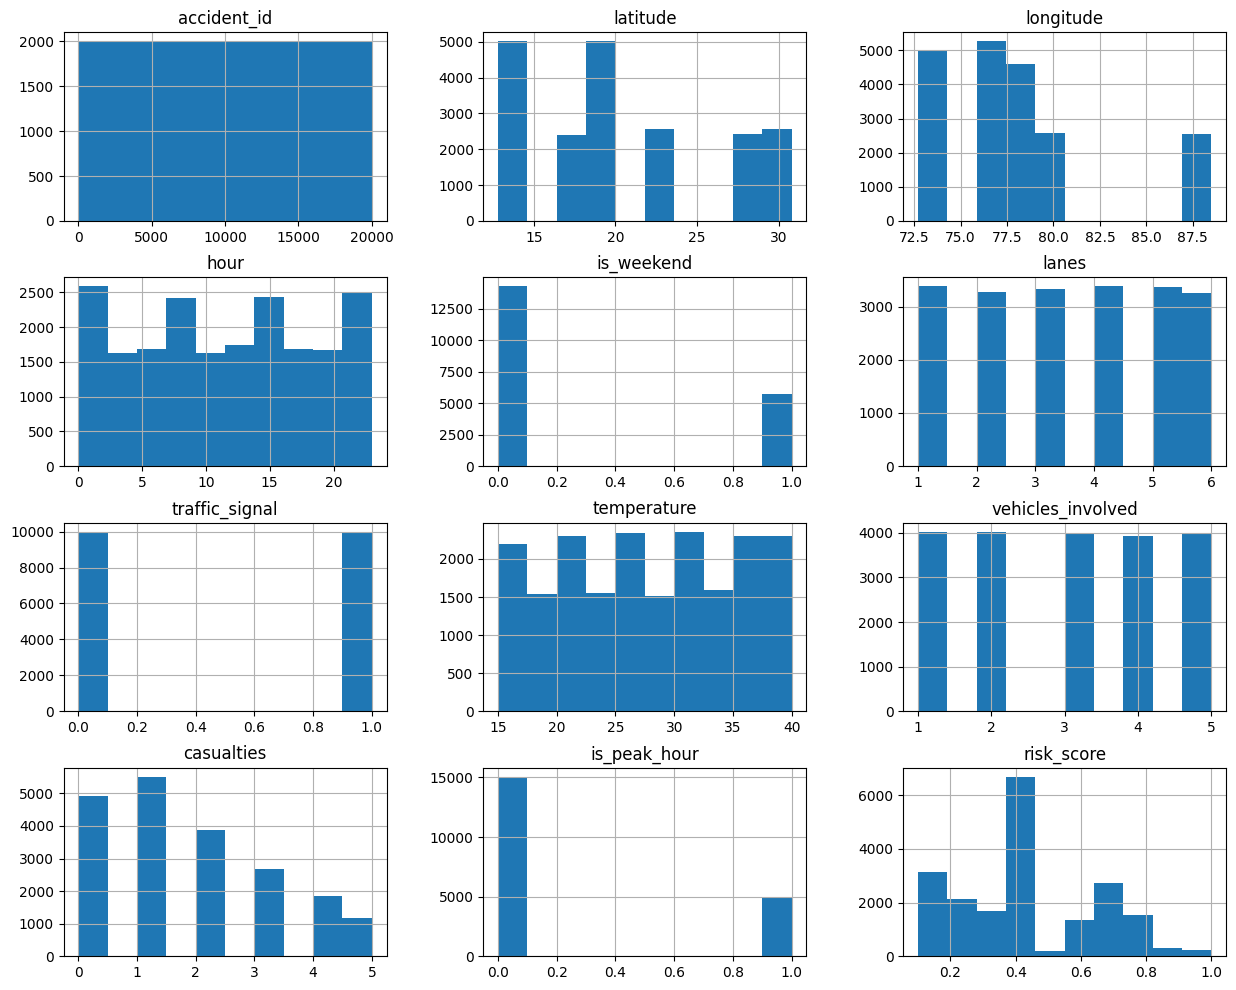

In [ ]:
#univariate analysis
df.hist(figsize=(15,12))
plt.show()

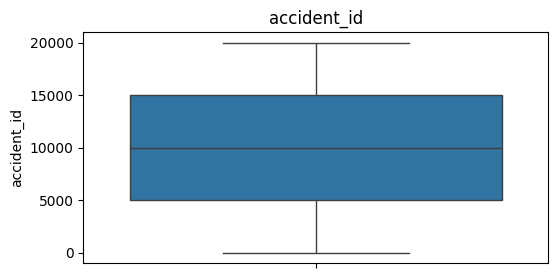

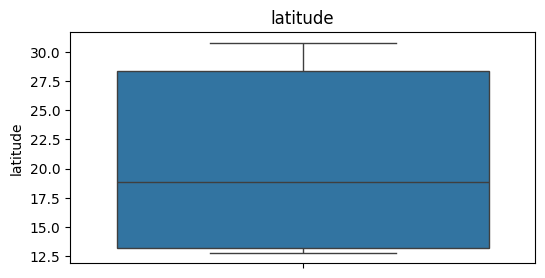

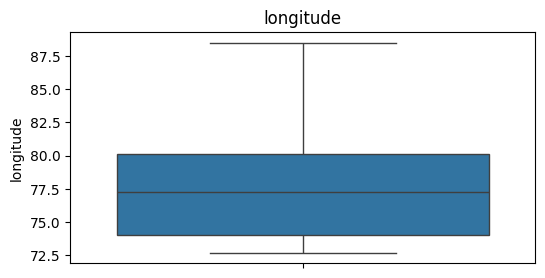

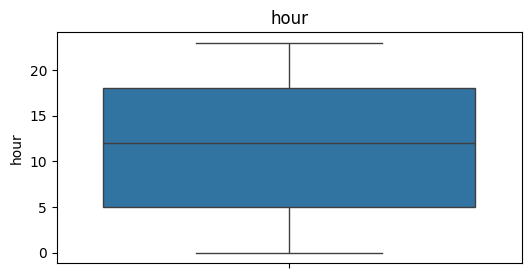

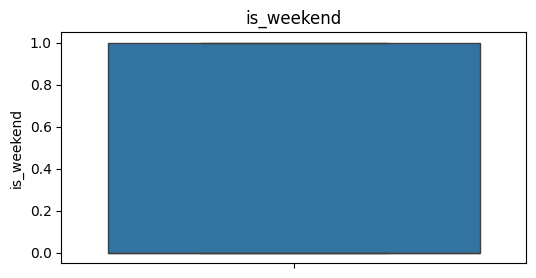

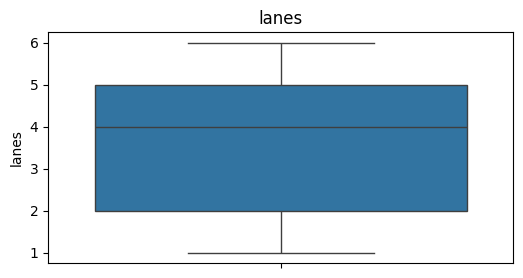

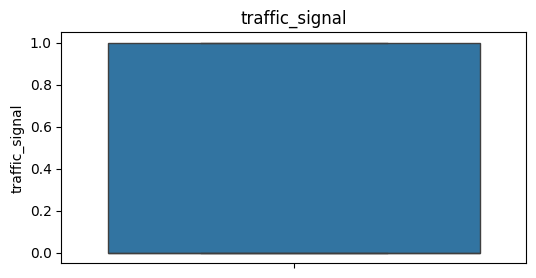

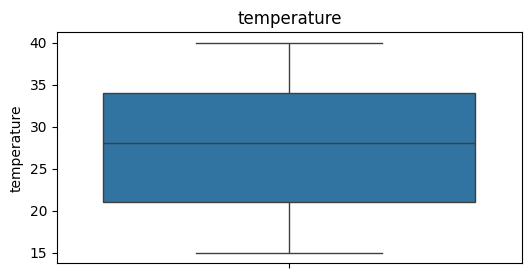

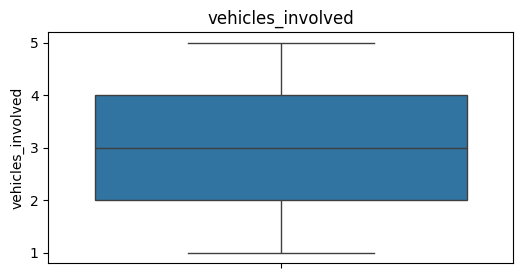

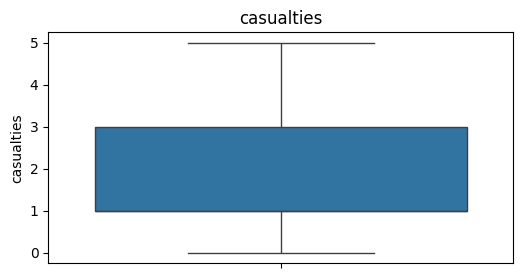

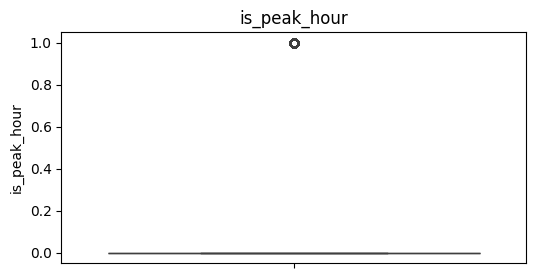

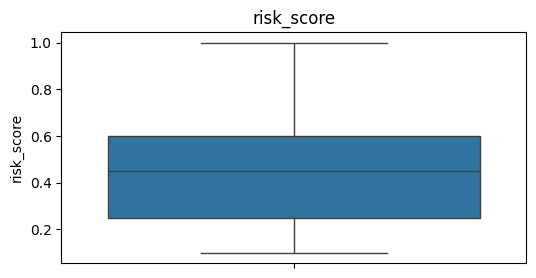

In [ ]:
#box plot
for col in num_cols:
  plt.figure(figsize=(6,3))
  sns.boxplot(df[col])
  plt.title(col)
  plt.show()

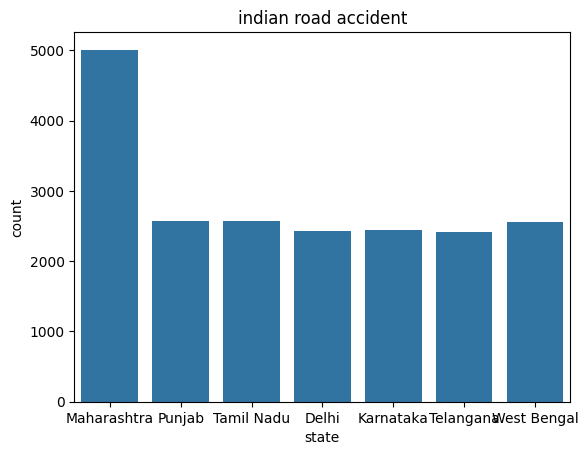

In [ ]:
#categorical analysis
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='state', data=df)
plt.title("indian road accident")
plt.show()

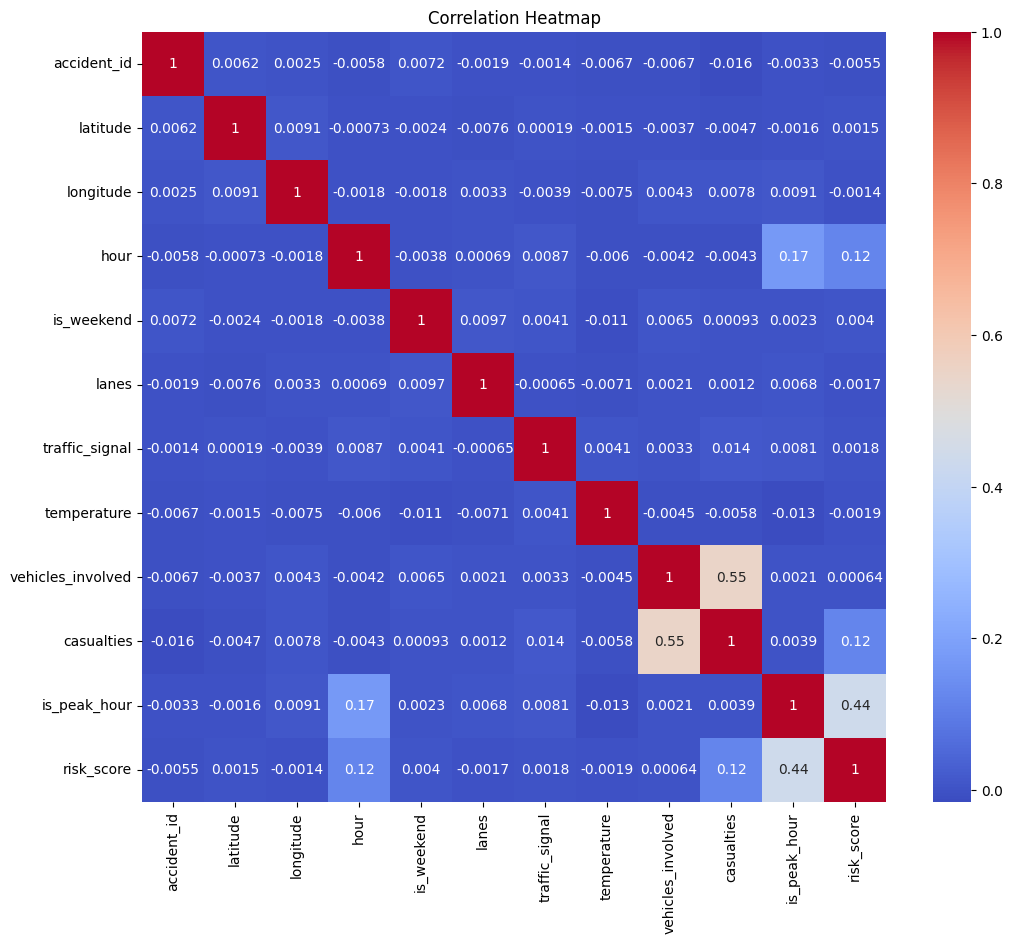

In [ ]:
#multivariate analysis
#heat map
coor = df.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(coor, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

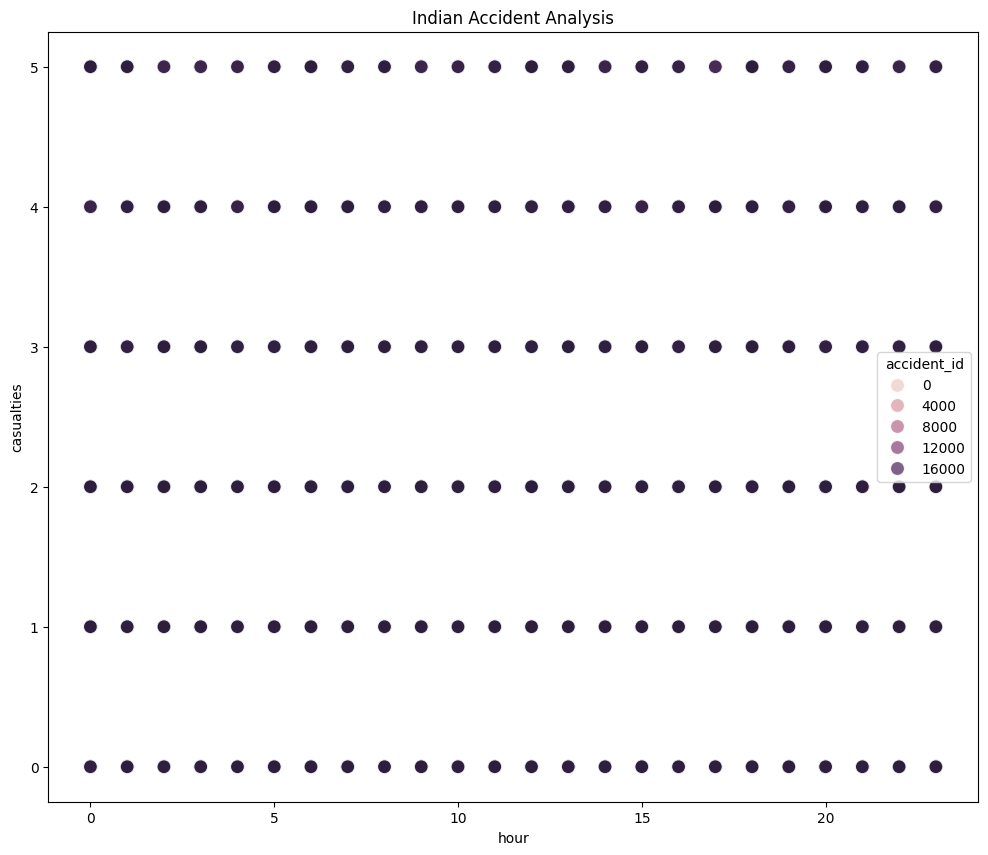

In [ ]:
#scatter plot
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("/content/archive (2).zip")
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='hour',y='casualties',hue='accident_id',data=df,s=100,alpha=0.8
)
plt.title('Indian Accident Analysis')
plt.show()

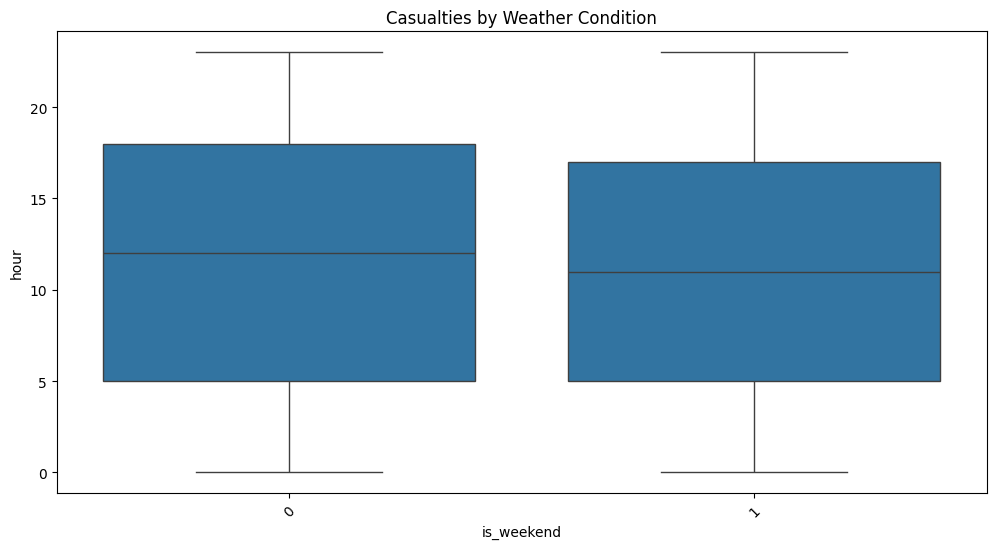

In [ ]:
#box plot
plt.figure(figsize=(12, 6))

sns.boxplot(
    x='is_weekend',
    y='hour',
    data=df
)
plt.title('Casualties by Weather Condition')
plt.xticks(rotation=45)
plt.show()

In [ ]:

print(df.isnull().sum())

accident_id          0
city                 0
state                0
latitude             0
longitude            0
date                 0
time                 0
hour                 0
day_of_week          0
is_weekend           0
road_type            0
lanes                0
traffic_signal       0
weather              0
visibility           0
temperature          0
traffic_density      0
cause                0
accident_severity    0
vehicles_involved    0
casualties           0
is_peak_hour         0
festival             0
risk_score           0
dtype: int64


In [ ]:
df.describe()

,accident_id,latitude,longitude,hour,is_weekend,lanes,traffic_signal,temperature,vehicles_involved,casualties,is_peak_hour,risk_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,9999.500000,20.389207,78.173330,11.487200,0.286150,3.493950,0.499850,27.579600,2.992000,1.726450,0.247400,0.437585
std,5773.647028,6.165791,4.485967,6.945563,0.451972,1.705406,0.500012,7.454746,1.415534,1.489104,0.431512,0.218130
min,0.000000,12.800172,72.700017,0.000000,0.000000,1.000000,0.000000,15.000000,1.000000,0.000000,0.000000,0.100000
25%,4999.750000,13.198653,73.997979,5.000000,0.000000,2.000000,0.000000,21.000000,2.000000,1.000000,0.000000,0.250000
50%,9999.500000,18.812008,77.297000,12.000000,0.000000,4.000000,0.000000,28.000000,3.000000,1.000000,0.000000,0.450000
75%,14999.250000,28.402467,80.111089,18.000000,1.000000,5.000000,1.000000,34.000000,4.000000,3.000000,0.000000,0.600000
max,19999.000000,30.799960,88.499861,23.000000,1.000000,6.000000,1.000000,40.000000,5.000000,5.000000,1.000000,1.000000


In [ ]:
df.select_dtypes(include='object').columns

Index(['city', 'state', 'date', 'time', 'day_of_week', 'road_type', 'weather',
       'visibility', 'traffic_density', 'cause', 'accident_severity',
       'festival'],
      dtype='object')

In [ ]:
#Final Summary & Insights
#1.The dataset contains no missing values.
#2.Numerical features have different value ranges.
#3.Categorical columns such as Gender and City are present.
#Model Readiness:
#The dataset is mostly model-ready. However, numerical features may need scaling and categorical features require encoding before training a machine learning model.